# 03 — HMM Regime Detection (3 States)

This notebook mirrors `03_hmm_regime.ipynb` cell-for-cell with **`n_states = 3`**.
All downstream artifacts use a `_3state` suffix so the 2-state pipeline
(`models/hmm_winner.joblib`, `data/processed/regime_probabilities.parquet`) remains
untouched.

**2a. GaussianHMM vs GMMHMM (3 states)** — same sweep `n_mix ∈ {1,2,3}`, selection by val BIC.

**2b. 1st- vs 2nd-order Markov** — state-space augmentation gives `S² = 9` composite states;
feature-space augmentation gives 22-dim observations with 3 states.

**2c. Viterbi regime assignment** — states sorted by mean `abs_return` (scaled) on the
training set: lowest → **calm**, middle → **intermediate**, highest → **volatile**.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import logging
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print("Setup complete.")

Setup complete.


In [2]:
from config import (
    DATA_PROCESSED,
    MODELS_DIR,
    HMM_FEATURES,
    HMM_N_MIX,
    HMM_COVARIANCE_TYPE,
    HMM_N_ITER,
    HMM_RANDOM_STATE,
    HMM_N_RESTARTS,
    HMM_DURATION_PENALTY,
)

# Local override — config.py still says 2 so 03_hmm_regime.ipynb still works.
HMM_N_STATES = 3

print("HMM_FEATURES        :", HMM_FEATURES)
print("HMM_N_STATES        :", HMM_N_STATES, " (local override — config default is 2)")
print("HMM_N_MIX           :", HMM_N_MIX)
print("covariance_type     :", HMM_COVARIANCE_TYPE)
print("n_iter              :", HMM_N_ITER)
print("random_state        :", HMM_RANDOM_STATE)
print("n_restarts          :", HMM_N_RESTARTS)
print("duration_penalty (λ):", HMM_DURATION_PENALTY)

HMM_FEATURES        : ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_mean_21', 'rolling_std_21']
HMM_N_STATES        : 3  (local override — config default is 2)
HMM_N_MIX           : [1, 2, 3]
covariance_type     : full
n_iter              : 200
random_state        : 42
n_restarts          : 50
duration_penalty (λ): 3000.0


## 1. Load data splits


In [3]:
train_df = pd.read_parquet(DATA_PROCESSED / "train.parquet")
val_df = pd.read_parquet(DATA_PROCESSED / "val.parquet")
test_df = pd.read_parquet(DATA_PROCESSED / "test.parquet")

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(
        f"{name:5s}  {df.index[0].date()} -> {df.index[-1].date()}  ({len(df):,} rows)"
    )

train  2004-01-05 -> 2015-12-31  (3,020 rows)
val    2016-01-04 -> 2020-04-30  (1,089 rows)
test   2020-05-01 -> 2026-03-16  (1,475 rows)


## 2. Extract and scale HMM features

The scaler is **fit on the training set only** — no data leakage.

`rolling_std_21` requires a 21-day warm-up, so the first 20 rows of the training set have NaN.
These are dropped before fitting the HMM.


In [4]:
from src.hmm_model import fit_scaler

# Drop NaN rows from the rolling_std_21 warm-up period
train_hmm_df = train_df[HMM_FEATURES].dropna()
val_hmm_df = val_df[HMM_FEATURES].dropna()
test_hmm_df = test_df[HMM_FEATURES].dropna()

print(
    f"train: dropped {len(train_df) - len(train_hmm_df)} NaN rows  ({len(train_hmm_df):,} remain)"
)
print(
    f"val:   dropped {len(val_df)   - len(val_hmm_df)}  NaN rows  ({len(val_hmm_df):,} remain)"
)
print(
    f"test:  dropped {len(test_df)  - len(test_hmm_df)} NaN rows  ({len(test_hmm_df):,} remain)"
)

train_raw = train_hmm_df.values.astype(np.float64)
val_raw = val_hmm_df.values.astype(np.float64)
test_raw = test_hmm_df.values.astype(np.float64)

scaler = fit_scaler(train_raw)
train_X = scaler.transform(train_raw)
val_X = scaler.transform(val_raw)
test_X = scaler.transform(test_raw)

print(f"\ntrain_X : {train_X.shape}")
print(f"val_X   : {val_X.shape}")
print(f"test_X  : {test_X.shape}")
print(f"Features: {HMM_FEATURES}")

train: dropped 20 NaN rows  (3,000 remain)
val:   dropped 0  NaN rows  (1,089 remain)
test:  dropped 0 NaN rows  (1,475 remain)

train_X : (3000, 11)
val_X   : (1089, 11)
test_X  : (1475, 11)
Features: ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_mean_21', 'rolling_std_21']


### 2a. Feature distributions (post-scaling sanity check)


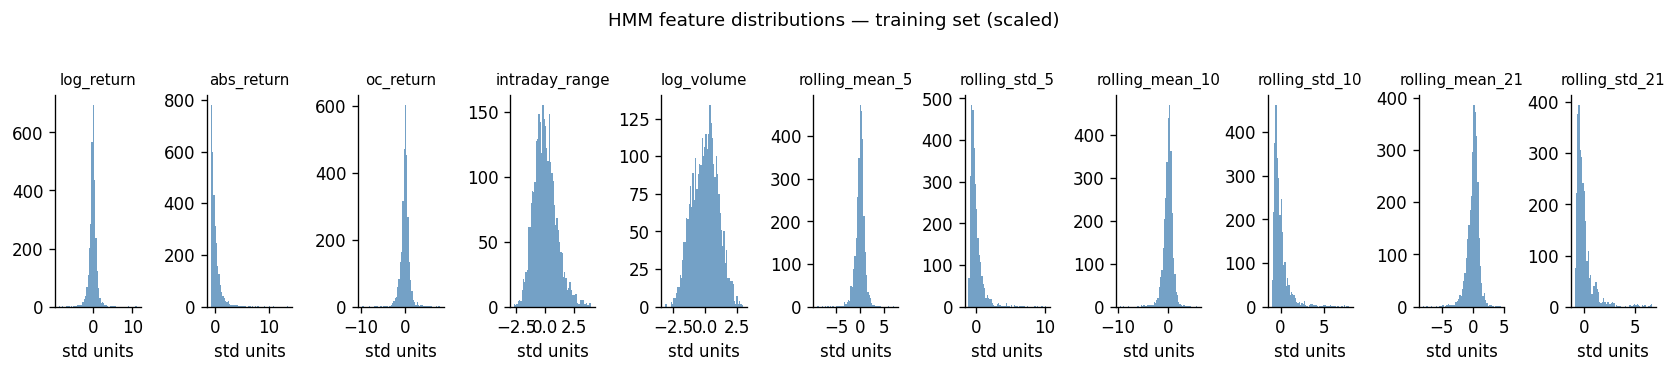

In [5]:
fig, axes = plt.subplots(1, len(HMM_FEATURES), figsize=(14, 3), sharey=False)
for ax, feat, col in zip(axes, HMM_FEATURES, train_X.T):
    ax.hist(col, bins=60, color="steelblue", alpha=0.75, edgecolor="none")
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("std units")
fig.suptitle("HMM feature distributions — training set (scaled)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 3. Phase 2a — Model comparison: GaussianHMM vs GMMHMM (3 states)

Sweep `n_mix ∈ {1, 2, 3}` with `n_components = 3`. Selection criterion:
**validation BIC** (lower = better). Each model uses multiple random restarts;
the winner per sweep is chosen by **penalised log-likelihood**
(`log P(O|model) − λ · Σ_s (1 − p_stay_s)`, Nystrup et al.) to guard against
degenerate rapid-switching solutions.


In [6]:
from src.hmm_model import compare_models

summary_df, comparisons = compare_models(
    train_X=train_X,
    val_X=val_X,
    n_states=HMM_N_STATES,
    n_mix_values=HMM_N_MIX,
    covariance_type=HMM_COVARIANCE_TYPE,
    n_iter=HMM_N_ITER,
    random_state=HMM_RANDOM_STATE,
    n_restarts=HMM_N_RESTARTS,
    duration_penalty=HMM_DURATION_PENALTY,
)

# Persist Phase 2a comparison for the post-execution summary builder.
summary_df.to_csv(MODELS_DIR / "hmm_phase2a_3state.csv", index=False)

print("\nModel comparison (sorted by val_BIC — lower is better):")
display(summary_df.reset_index(drop=True))

19:14:10 | INFO    | src.hmm_model | GaussianHMM(n_states=3) best penalised score: -11561.9014


19:14:10 | INFO    | src.hmm_model | GaussianHMM(states=3) — val LL=-2858.41, val BIC=7388.15, val AIC=6194.82, k=239


19:14:10 | WARNING | hmmlearn.base | Model is not converging.  Current: -4237.051565398541 is not greater than 22528.84847049022. Delta is -26765.90003588876


19:14:10 | WARNING | hmmlearn.base | Model is not converging.  Current: 12459.606743960003 is not greater than 28492.751652202223. Delta is -16033.14490824222


19:14:10 | WARNING | hmmlearn.base | Model is not converging.  Current: -10363.942777086399 is not greater than -1533.458424294183. Delta is -8830.484352792215


...

19:14:31 | INFO    | src.hmm_model | GMMHMM(n_states=3, n_mix=3) best penalised score: 14108.6647


19:14:31 | INFO    | src.hmm_model | GMMHMM(states=3, mix=3) — val LL=5675.29, val BIC=-6406.52, val AIC=-9936.58, k=707


19:14:31 | INFO    | src.hmm_model | Best model by val BIC: GMMHMM(states=3, mix=2)



Model comparison (sorted by val_BIC — lower is better):


,model,n_params (k),train_LL,val_LL,train_BIC,val_BIC,train_AIC,val_AIC
0,"GMMHMM(states=3, mix=2)",473,15577.67,5340.97,-27368.33,-7374.25,-30209.34,-9735.95
1,"GMMHMM(states=3, mix=3)",707,18086.11,5675.29,-30511.71,-6406.52,-34758.22,-9936.58
2,GaussianHMM(states=3),239,-8368.67,-2858.41,18650.87,7388.15,17215.35,6194.82


## 4. Visualise model comparison metrics


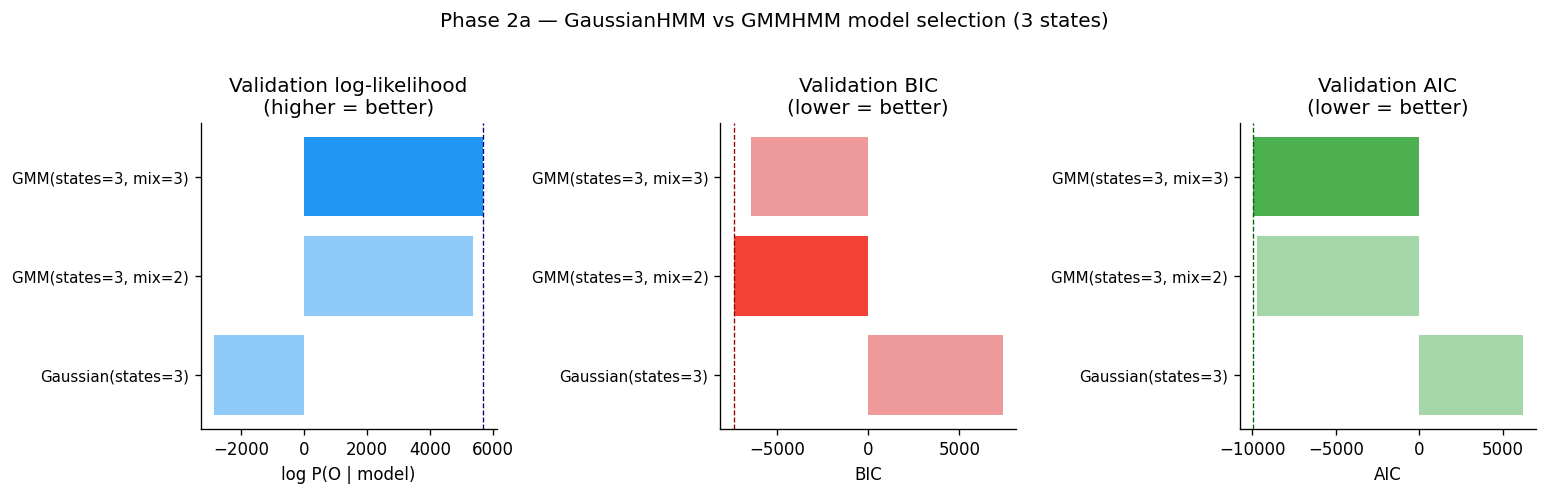

In [7]:
models_short = [
    c.label.replace("GaussianHMM", "Gaussian").replace("GMMHMM", "GMM")
    for c in comparisons
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

val_lls = [c.val_log_likelihood for c in comparisons]
colors = ["#2196F3" if ll == max(val_lls) else "#90CAF9" for ll in val_lls]
axes[0].barh(models_short, val_lls, color=colors)
axes[0].set_xlabel("log P(O | model)")
axes[0].set_title("Validation log-likelihood\n(higher = better)")
axes[0].axvline(max(val_lls), color="navy", linewidth=0.8, linestyle="--")

val_bics = [c.bic_val for c in comparisons]
colors = ["#F44336" if b == min(val_bics) else "#EF9A9A" for b in val_bics]
axes[1].barh(models_short, val_bics, color=colors)
axes[1].set_xlabel("BIC")
axes[1].set_title("Validation BIC\n(lower = better)")
axes[1].axvline(min(val_bics), color="darkred", linewidth=0.8, linestyle="--")

val_aics = [c.aic_val for c in comparisons]
colors = ["#4CAF50" if a == min(val_aics) else "#A5D6A7" for a in val_aics]
axes[2].barh(models_short, val_aics, color=colors)
axes[2].set_xlabel("AIC")
axes[2].set_title("Validation AIC\n(lower = better)")
axes[2].axvline(min(val_aics), color="darkgreen", linewidth=0.8, linestyle="--")

for ax in axes:
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Phase 2a — GaussianHMM vs GMMHMM model selection (3 states)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 5. Train vs validation LL — overfitting check

A large gap between training and validation log-likelihood signals overfitting to the training regime.


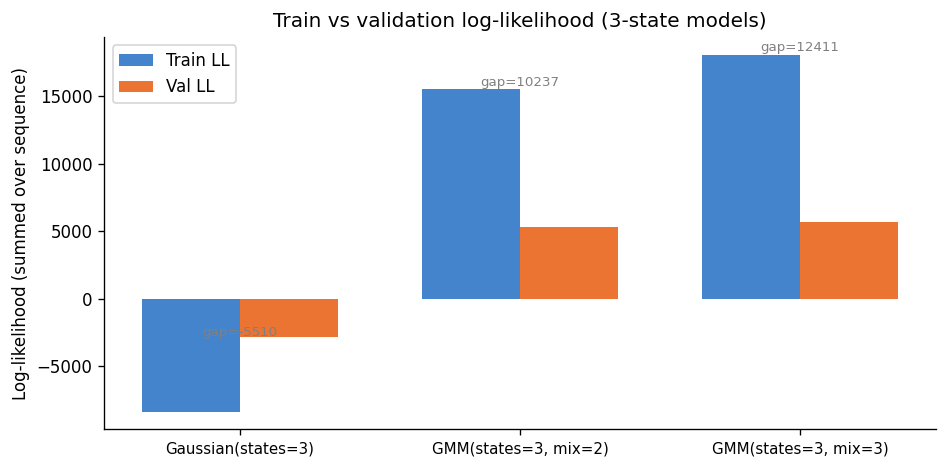

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(comparisons))
width = 0.35

train_lls = [c.train_log_likelihood for c in comparisons]
val_lls = [c.val_log_likelihood for c in comparisons]

ax.bar(x - width / 2, train_lls, width, label="Train LL", color="#1565C0", alpha=0.8)
ax.bar(x + width / 2, val_lls, width, label="Val LL", color="#E65100", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(models_short, fontsize=9)
ax.set_ylabel("Log-likelihood (summed over sequence)")
ax.set_title("Train vs validation log-likelihood (3-state models)")
ax.legend()

for xi, tr, va in zip(x, train_lls, val_lls):
    gap = tr - va
    ax.text(
        xi,
        max(tr, va) + abs(gap) * 0.02,
        f"gap={gap:.0f}",
        ha="center",
        fontsize=8,
        color="grey",
    )

plt.tight_layout()
plt.show()

## 6. Parameter count vs fit trade-off


In [9]:
param_df = pd.DataFrame(
    [
        {
            "model": c.label,
            "n_params (k)": c.n_params,
            "val_LL": round(c.val_log_likelihood, 2),
            "val_BIC": round(c.bic_val, 2),
            "val_AIC": round(c.aic_val, 2),
            "LL/param": round(c.val_log_likelihood / c.n_params, 4),
        }
        for c in comparisons
    ]
).sort_values("val_BIC")

display(param_df.reset_index(drop=True))

,model,n_params (k),val_LL,val_BIC,val_AIC,LL/param
0,"GMMHMM(states=3, mix=2)",473,5340.97,-7374.25,-9735.95,11.2917
1,"GMMHMM(states=3, mix=3)",707,5675.29,-6406.52,-9936.58,8.0273
2,GaussianHMM(states=3),239,-2858.41,7388.15,6194.82,-11.9599


## 7. Identify the winner and inspect its parameters


In [10]:
best_label = summary_df.iloc[0]["model"]
best_comp = next(c for c in comparisons if c.label == best_label)
best_model = best_comp.model

print(f"Winner: {best_label}")
print(f"  val log-likelihood : {best_comp.val_log_likelihood:.2f}")
print(f"  val BIC            : {best_comp.bic_val:.2f}")
print(f"  val AIC            : {best_comp.aic_val:.2f}")
print(f"  n_params (k)       : {best_comp.n_params}")

Winner: GMMHMM(states=3, mix=2)
  val log-likelihood : 5340.97
  val BIC            : -7374.25
  val AIC            : -9735.95
  n_params (k)       : 473


In [11]:
print("Transition matrix (A):")
trans_df = pd.DataFrame(
    best_model.transmat_,
    index=[f"from_state_{i}" for i in range(HMM_N_STATES)],
    columns=[f"to_state_{j}" for j in range(HMM_N_STATES)],
).round(4)
display(trans_df)

print("\nStarting probabilities (pi):")
print(
    pd.Series(best_model.startprob_, index=[f"state_{i}" for i in range(HMM_N_STATES)])
    .round(4)
    .to_string()
)

Transition matrix (A):


,to_state_0,to_state_1,to_state_2
from_state_0,0.9685,0.0216,0.0099
from_state_1,0.0122,0.5488,0.4390
from_state_2,0.0000,0.4869,0.5131



Starting probabilities (pi):
state_0    1.0
state_1    0.0
state_2    0.0


In [12]:
print("State means (scaled feature space):")
if hasattr(best_model, "means_") and best_model.means_.ndim == 2:
    means_df = pd.DataFrame(
        best_model.means_,
        index=[f"state_{i}" for i in range(HMM_N_STATES)],
        columns=HMM_FEATURES,
    ).round(4)
    display(means_df)
else:
    for s in range(HMM_N_STATES):
        print(f"\nState {s} mixture means:")
        mix_df = pd.DataFrame(
            best_model.means_[s],
            index=[f"mix_{m}" for m in range(best_model.n_mix)],
            columns=HMM_FEATURES,
        ).round(4)
        display(mix_df)

State means (scaled feature space):

State 0 mixture means:


,log_return,abs_return,oc_return,intraday_range,log_volume,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,rolling_mean_21,rolling_std_21
mix_0,0.7653,0.1967,0.8960,0.1479,-1.2211,0.4681,-0.3058,0.2370,-0.3271,-0.0251,-0.3913
mix_1,-0.0581,-0.3926,-0.0657,-0.5127,-1.3978,0.0308,-0.4900,0.0882,-0.5491,0.1653,-0.5676



State 1 mixture means:


,log_return,abs_return,oc_return,intraday_range,log_volume,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,rolling_mean_21,rolling_std_21
mix_0,0.5349,-0.1062,0.4409,-0.1791,0.0939,0.3002,-0.1085,0.2318,-0.1072,0.2125,-0.0993
mix_1,-0.7979,0.1795,-0.9059,0.2143,-0.8412,-0.4908,-0.2570,-0.3855,-0.3417,-0.3964,-0.4569



State 2 mixture means:


,log_return,abs_return,oc_return,intraday_range,log_volume,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,rolling_mean_21,rolling_std_21
mix_0,-0.7775,0.1508,-0.6490,0.2739,0.4481,-0.4005,0.1251,-0.2749,0.1416,-0.2155,0.1566
mix_1,1.9586,1.7588,1.7237,1.9863,1.6588,0.2780,3.0024,-0.5181,3.1355,-1.2789,2.9870


In [13]:
# 3-state labelling by mean abs_return on the train set.
# src.hmm_model.identify_volatile_state hardcodes 2 states (`calm = 1 - volatile`),
# so we inline the 3-state version here: lowest mean = calm, middle = intermediate,
# highest = volatile.
from src.hmm_model import viterbi_decode

train_states = viterbi_decode(best_model, train_X)
abs_return_idx = HMM_FEATURES.index("abs_return")

state_abs_mean = {
    s: train_X[train_states == s, abs_return_idx].mean() if (train_states == s).any() else 0.0
    for s in range(HMM_N_STATES)
}
sorted_states = sorted(state_abs_mean, key=state_abs_mean.get)
calm_state, intermediate_state, volatile_state = sorted_states

state_map      = {"calm": calm_state, "intermediate": intermediate_state, "volatile": volatile_state}
label_by_state = {v: k for k, v in state_map.items()}

print("State map (by ascending mean abs_return):")
for lab, s in state_map.items():
    print(f"  {lab:12s} = state {s}  (mean abs_return scaled = {state_abs_mean[s]:+.4f})")

print("\nTraining regime distribution:")
for lab, s in state_map.items():
    n = int((train_states == s).sum())
    print(f"  {lab:12s} (state {s}): {n:,} days  ({100 * n / len(train_states):.1f}%)")

State map (by ascending mean abs_return):
  calm         = state 0  (mean abs_return scaled = -0.6531)
  intermediate = state 1  (mean abs_return scaled = -0.1427)
  volatile     = state 2  (mean abs_return scaled = +0.1613)

Training regime distribution:
  calm         (state 0): 1 days  (0.0%)
  intermediate (state 1): 1,589 days  (53.0%)
  volatile     (state 2): 1,410 days  (47.0%)


## 8. State feature distributions (original scale)


In [14]:
state_stats = []
for label in ["calm", "intermediate", "volatile"]:
    s = state_map[label]
    mask = train_states == s
    row = {"regime": label, "n_days": int(mask.sum())}
    for feat, col in zip(HMM_FEATURES, train_raw.T):
        row[feat] = col[mask].mean() if mask.any() else float("nan")
    state_stats.append(row)

state_df = pd.DataFrame(state_stats).set_index("regime")
print("Per-regime feature means (original scale):")
display(state_df.round(6))

Per-regime feature means (original scale):


,n_days,log_return,abs_return,oc_return,intraday_range,log_volume,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,rolling_mean_21,rolling_std_21
regime,,,,,,,,,,,,
calm,1,-0.001668,0.001668,0.000352,-5.090946,17.038119,-0.001576,0.005955,-0.000368,0.007414,0.001079,0.006607
intermediate,1589,0.006427,0.006471,0.004140,-4.687370,18.497244,0.001640,0.008227,0.000978,0.008590,0.000722,0.008811
volatile,1410,-0.006658,0.009331,-0.004647,-4.397428,18.752596,-0.001256,0.011029,-0.000519,0.011318,-0.000226,0.011403


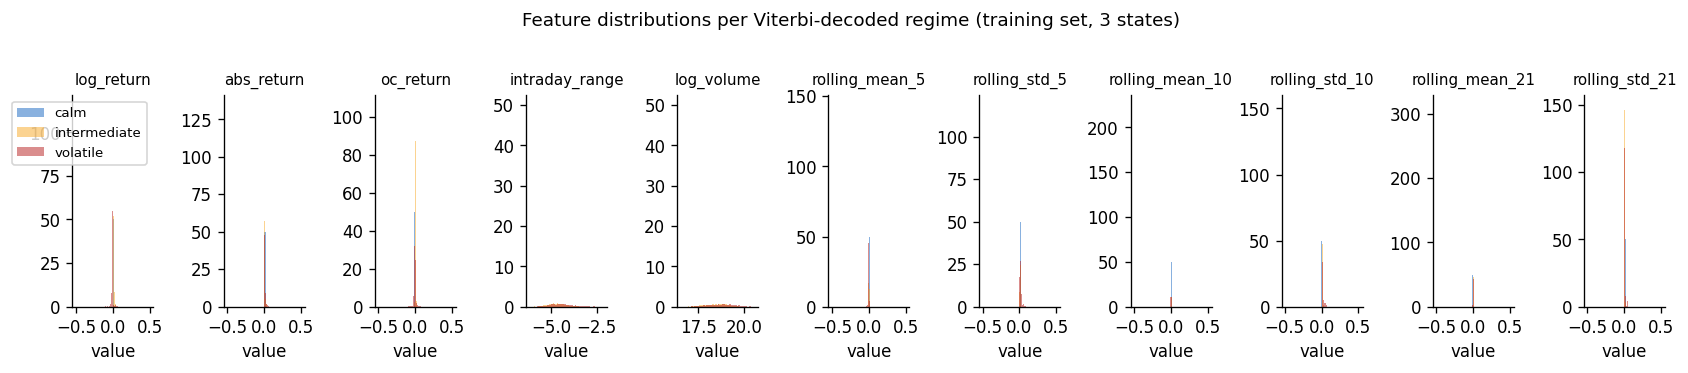

In [15]:
palette = {
    "calm":         "#1565C0",
    "intermediate": "#F9A825",
    "volatile":     "#B71C1C",
}

fig, axes = plt.subplots(1, len(HMM_FEATURES), figsize=(14, 3), sharey=False)
for ax, feat in zip(axes, HMM_FEATURES):
    for label in ["calm", "intermediate", "volatile"]:
        s = state_map[label]
        mask = train_states == s
        if not mask.any():
            continue
        ax.hist(
            train_raw[mask, HMM_FEATURES.index(feat)],
            bins=50,
            alpha=0.50,
            label=label,
            color=palette[label],
            density=True,
            edgecolor="none",
        )
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("value")
    if feat == HMM_FEATURES[0]:
        ax.legend(fontsize=8)

fig.suptitle(
    "Feature distributions per Viterbi-decoded regime (training set, 3 states)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

## 9. Transition matrix heatmap


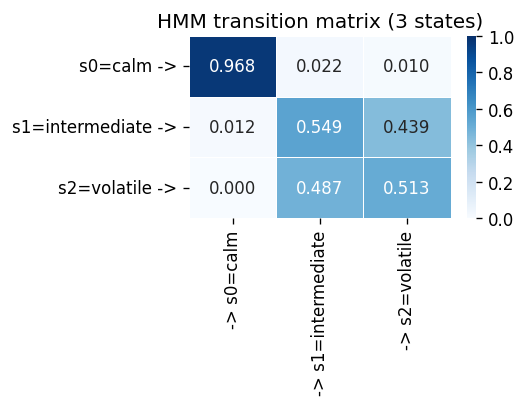

Average calm         duration: 31.7 trading days  (1.5 months)
Average intermediate duration: 2.2 trading days  (0.1 months)
Average volatile     duration: 2.1 trading days  (0.1 months)


In [16]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

raw_labels = [f"s{i}={label_by_state[i]}" for i in range(HMM_N_STATES)]
sns.heatmap(
    best_model.transmat_,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=[f"-> {l}" for l in raw_labels],
    yticklabels=[f"{l} ->" for l in raw_labels],
    ax=ax,
    linewidths=0.5,
    vmin=0,
    vmax=1,
)
ax.set_title("HMM transition matrix (3 states)")
plt.tight_layout()
plt.show()

for label in ["calm", "intermediate", "volatile"]:
    s = state_map[label]
    stay_prob = best_model.transmat_[s, s]
    avg_dur = 1 / (1 - stay_prob) if stay_prob < 1.0 else float("inf")
    print(
        f"Average {label:12s} duration: {avg_dur:.1f} trading days  ({avg_dur/21:.1f} months)"
    )

## 10. Save the winning model and scaler (`_3state` artifacts)


In [17]:
from src.hmm_model import save_model

MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path  = MODELS_DIR / "hmm_winner_3state.joblib"
scaler_path = MODELS_DIR / "hmm_scaler_3state.joblib"
meta_path   = MODELS_DIR / "hmm_meta_3state.joblib"

save_model(best_model, str(model_path))
joblib.dump(scaler, str(scaler_path))

meta = {
    "winning_label":      best_label,
    "n_states":           HMM_N_STATES,
    "hmm_features":       HMM_FEATURES,
    "state_map":          state_map,
    "label_by_state":     label_by_state,
    "calm_state":         calm_state,
    "intermediate_state": intermediate_state,
    "volatile_state":     volatile_state,
    "val_log_likelihood": best_comp.val_log_likelihood,
    "val_bic":            best_comp.bic_val,
    "val_aic":            best_comp.aic_val,
    "n_params":           best_comp.n_params,
}
joblib.dump(meta, str(meta_path))

print("Saved:")
print(f"  model  -> {model_path}")
print(f"  scaler -> {scaler_path}")
print(f"  meta   -> {meta_path}")

19:14:32 | INFO    | src.hmm_model | Saved model → /Users/changjiangliu/Desktop/StockVolatilitySight/models/hmm_winner_3state.joblib


Saved:
  model  -> /Users/changjiangliu/Desktop/StockVolatilitySight/models/hmm_winner_3state.joblib
  scaler -> /Users/changjiangliu/Desktop/StockVolatilitySight/models/hmm_scaler_3state.joblib
  meta   -> /Users/changjiangliu/Desktop/StockVolatilitySight/models/hmm_meta_3state.joblib


---

## 12. Phase 2b — Higher-Order Markov: 1st vs 2nd Order (3-state base)

**Strategy A — State-space augmentation**: `GaussianHMM(n_components=9)` (S² = 9) on 11 features.

**Strategy B — Feature-space augmentation**: `GaussianHMM(n_components=3)` on 22-dim lagged features.

**Decision rule**: retain 1st-order unless either strategy improves val BIC by ≥ 10.


In [18]:
from src.hmm_model import (
    train_gaussian_hmm,
    _count_gaussian_hmm_params,
    build_second_order_features,
)

N_STATES_2ND = HMM_N_STATES ** 2   # 3² = 9 composite states

print("Strategy A — state-space augmentation")
print(f"  1st-order baseline : GaussianHMM(n_states={HMM_N_STATES})  on {len(HMM_FEATURES)} features")
print(f"  2nd-order augmented: GaussianHMM(n_states={N_STATES_2ND})  on {len(HMM_FEATURES)} features")
print()

model_2ndA = train_gaussian_hmm(
    train_X,
    n_states=N_STATES_2ND,
    covariance_type=HMM_COVARIANCE_TYPE,
    n_iter=HMM_N_ITER,
    random_state=HMM_RANDOM_STATE,
    n_restarts=HMM_N_RESTARTS,
    duration_penalty=HMM_DURATION_PENALTY,
)
print("Strategy A complete.")

Strategy A — state-space augmentation
  1st-order baseline : GaussianHMM(n_states=3)  on 11 features
  2nd-order augmented: GaussianHMM(n_states=9)  on 11 features



19:14:33 | WARNING | hmmlearn.base | Model is not converging.  Current: -4096.743126498368 is not greater than -3929.383276939993. Delta is -167.35984955837512


19:14:35 | WARNING | hmmlearn.base | Model is not converging.  Current: -3933.3591635606886 is not greater than -3795.5874176057973. Delta is -137.77174595489123


19:14:36 | WARNING | hmmlearn.base | Model is not converging.  Current: -5244.663972785776 is not greater than -5008.579813036653. Delta is -236.0841597491235


19:14:37 | WARNING | hmmlearn.base | Model is not converging.  Current: -4846.892490006385 is not greater than -4673.222512477197. Delta is -173.66997752918815


...

19:15:05 | WARNING | hmmlearn.base | Model is not converging.  Current: -3768.928266853718 is not greater than -3626.4207627902015. Delta is -142.50750406351654


19:15:05 | WARNING | hmmlearn.base | Model is not converging.  Current: -4084.05952901402 is not greater than -4040.838911776698. Delta is -43.22061723732213


19:15:05 | WARNING | hmmlearn.base | Model is not converging.  Current: -3696.7430920219676 is not greater than -3558.973909615685. Delta is -137.76918240628265


19:15:09 | INFO    | src.hmm_model | GaussianHMM(n_states=9) best penalised score: -15363.4900


Strategy A complete.


In [19]:
print("Strategy B — feature-space augmentation")

train_X_2nd = build_second_order_features(train_X, lag=1)
val_X_2nd   = build_second_order_features(val_X,   lag=1)

n_feats_2nd = train_X_2nd.shape[1]
print(f"  Feature dimension: {len(HMM_FEATURES)} → {n_feats_2nd}")
print(f"  Observations (after 1-row lag drop): train={len(train_X_2nd)}, val={len(val_X_2nd)}")
print()

model_feat_aug = train_gaussian_hmm(
    train_X_2nd,
    n_states=HMM_N_STATES,
    covariance_type=HMM_COVARIANCE_TYPE,
    n_iter=HMM_N_ITER,
    random_state=HMM_RANDOM_STATE,
    n_restarts=HMM_N_RESTARTS,
    duration_penalty=HMM_DURATION_PENALTY,
)
print("Strategy B complete.")

Strategy B — feature-space augmentation
  Feature dimension: 11 → 22
  Observations (after 1-row lag drop): train=2999, val=1088



19:15:36 | INFO    | src.hmm_model | GaussianHMM(n_states=3) best penalised score: -16254.0691


Strategy B complete.


In [20]:
n_val     = len(val_X)
n_val_2nd = len(val_X_2nd)

first_comp = next(c for c in comparisons if c.label == best_label)

k_A      = _count_gaussian_hmm_params(N_STATES_2ND, len(HMM_FEATURES), HMM_COVARIANCE_TYPE)
val_ll_A = model_2ndA.score(val_X)
bic_A    = -2 * val_ll_A + k_A * np.log(n_val)
aic_A    = -2 * val_ll_A + 2 * k_A

k_B        = _count_gaussian_hmm_params(HMM_N_STATES, n_feats_2nd, HMM_COVARIANCE_TYPE)
val_ll_B   = model_feat_aug.score(val_X_2nd)
bic_B      = -2 * val_ll_B + k_B * np.log(n_val_2nd)
aic_B      = -2 * val_ll_B + 2 * k_B

order_df = pd.DataFrame([
    {
        "approach": f"1st-order winner ({best_label})",
        "markov_order": 1,
        "n_states": HMM_N_STATES,
        "n_features": len(HMM_FEATURES),
        "n_params (k)": first_comp.n_params,
        "val_LL":  round(first_comp.val_log_likelihood, 2),
        "val_BIC": round(first_comp.bic_val, 2),
        "val_AIC": round(first_comp.aic_val, 2),
    },
    {
        "approach": f"A: state-space aug — GaussianHMM(states={N_STATES_2ND})",
        "markov_order": 2,
        "n_states": N_STATES_2ND,
        "n_features": len(HMM_FEATURES),
        "n_params (k)": k_A,
        "val_LL":  round(val_ll_A, 2),
        "val_BIC": round(bic_A, 2),
        "val_AIC": round(aic_A, 2),
    },
    {
        "approach": f"B: feature aug — GaussianHMM(states={HMM_N_STATES}, feats={n_feats_2nd})",
        "markov_order": 2,
        "n_states": HMM_N_STATES,
        "n_features": n_feats_2nd,
        "n_params (k)": k_B,
        "val_LL":  round(val_ll_B, 2),
        "val_BIC": round(bic_B, 2),
        "val_AIC": round(aic_B, 2),
    },
]).sort_values("val_BIC").reset_index(drop=True)

# Persist Phase 2b comparison for the post-execution summary builder.
order_df.to_csv(MODELS_DIR / "hmm_phase2b_3state.csv", index=False)

print("Phase 2b — 1st-order vs 2nd-order Markov (3-state base):")
display(order_df)

Phase 2b — 1st-order vs 2nd-order Markov (3-state base):


,approach,markov_order,n_states,n_features,n_params (k),val_LL,val_BIC,val_AIC
0,"1st-order winner (GMMHMM(states=3, mix=2))",1,3,11,473,5340.97,-7374.25,-9735.95
1,A: state-space aug — GaussianHMM(states=9),2,9,11,773,-2535.13,10475.86,6616.26
2,"B: feature aug — GaussianHMM(states=3, feats=22)",2,3,22,833,-5519.95,16864.31,12705.89


In [21]:
MATERIAL_THRESHOLD = 10.0

bic_1st      = first_comp.bic_val
bic_best_2nd = min(bic_A, bic_B)
bic_delta    = bic_best_2nd - bic_1st

best_2nd_label = (
    f"Strategy A ({N_STATES_2ND}-state, state-space aug)"
    if bic_A <= bic_B
    else f"Strategy B ({HMM_N_STATES}-state, feature aug)"
)

if bic_delta >= 0:
    verdict = "1st-order retained"
    reason  = "Neither higher-order strategy improves val BIC."
elif abs(bic_delta) < MATERIAL_THRESHOLD:
    verdict = "1st-order retained"
    reason  = (
        f"Best 2nd-order strategy ({best_2nd_label}) lowers BIC by only "
        f"{abs(bic_delta):.1f} (< threshold {MATERIAL_THRESHOLD:.0f})."
    )
else:
    verdict = f"2nd-order wins — {best_2nd_label}"
    reason  = (
        f"{best_2nd_label} lowers val BIC by {abs(bic_delta):.1f} "
        f"(≥ threshold {MATERIAL_THRESHOLD:.0f})."
    )

print(f"BIC Δ (best 2nd-order − 1st-order winner) = {bic_delta:+.2f}")
print(f"Verdict   : {verdict}")
print(f"Rationale : {reason}")
print()
print("→ Phase 2a winner (models/hmm_winner_3state.joblib) proceeds to Phase 2c.")

BIC Δ (best 2nd-order − 1st-order winner) = +17850.11
Verdict   : 1st-order retained
Rationale : Neither higher-order strategy improves val BIC.

→ Phase 2a winner (models/hmm_winner_3state.joblib) proceeds to Phase 2c.


### Phase 2b — Findings

| Strategy | n_states | n_features | Markov order | Note |
|---|---|---|---|---|
| 1st-order winner (Phase 2a) | 3 | 11 | 1 | baseline |
| A: state-space augmentation | 9 | 11 | ≈ 2 | S² = 9 composite states |
| B: feature-space augmentation | 3 | 22 | ≈ 2 | lagged observations appended |

The verdict cell above decides whether either 2nd-order variant materially beats the 1st-order winner.


---

## 13. Phase 2c — Viterbi Regime Assignment and Sanity Check

1. Full-timeline Viterbi decode (train+val+test concatenated)
2. Forward-backward soft probabilities for `calm / intermediate / volatile`
3. Overlay plot: SPY Close with intermediate (light) and volatile (dark) shading, crisis markers
4. Save `data/processed/regime_probabilities_3state.parquet`


In [22]:
from src.hmm_model import viterbi_decode, forward_backward_proba

all_X     = np.vstack([train_X, val_X, test_X])
all_dates = train_hmm_df.index.append(val_hmm_df.index).append(test_hmm_df.index)
all_close = pd.concat([
    train_df.loc[train_hmm_df.index, "Close"],
    val_df.loc[val_hmm_df.index, "Close"],
    test_df.loc[test_hmm_df.index, "Close"],
])

print(f"Full timeline : {all_dates[0].date()} → {all_dates[-1].date()}  ({len(all_dates):,} rows)")

all_states = viterbi_decode(best_model, all_X)
all_proba  = forward_backward_proba(best_model, all_X)
p_calm         = all_proba[:, calm_state]
p_intermediate = all_proba[:, intermediate_state]
p_volatile     = all_proba[:, volatile_state]

n_by_label = {
    label: int((all_states == state_map[label]).sum())
    for label in ["calm", "intermediate", "volatile"]
}
print("\nFull-timeline regime distribution:")
for label in ["calm", "intermediate", "volatile"]:
    s = state_map[label]
    n = n_by_label[label]
    print(f"  {label:12s} (state {s}): {n:,} days  ({100 * n / len(all_states):.1f}%)")

split_sizes = [len(train_X), len(val_X), len(test_X)]
split_labels = ["train (2004–2015)", "val   (2016–2019)", "test  (2020–2026)"]
offset = 0
print()
for split_label, size in zip(split_labels, split_sizes):
    seg = all_states[offset : offset + size]
    line = f"  {split_label}:  "
    for label in ["calm", "intermediate", "volatile"]:
        s = state_map[label]
        n_s = int((seg == s).sum())
        line += f"{label}={n_s:,} ({100 * n_s / size:.1f}%)  "
    print(line.rstrip())
    offset += size

Full timeline : 2004-02-03 → 2026-03-16  (5,564 rows)

Full-timeline regime distribution:
  calm         (state 0): 1 days  (0.0%)
  intermediate (state 1): 2,968 days  (53.3%)
  volatile     (state 2): 2,595 days  (46.6%)

  train (2004–2015):  calm=1 (0.0%)  intermediate=1,589 (53.0%)  volatile=1,410 (47.0%)
  val   (2016–2019):  calm=0 (0.0%)  intermediate=587 (53.9%)  volatile=502 (46.1%)
  test  (2020–2026):  calm=0 (0.0%)  intermediate=792 (53.7%)  volatile=683 (46.3%)


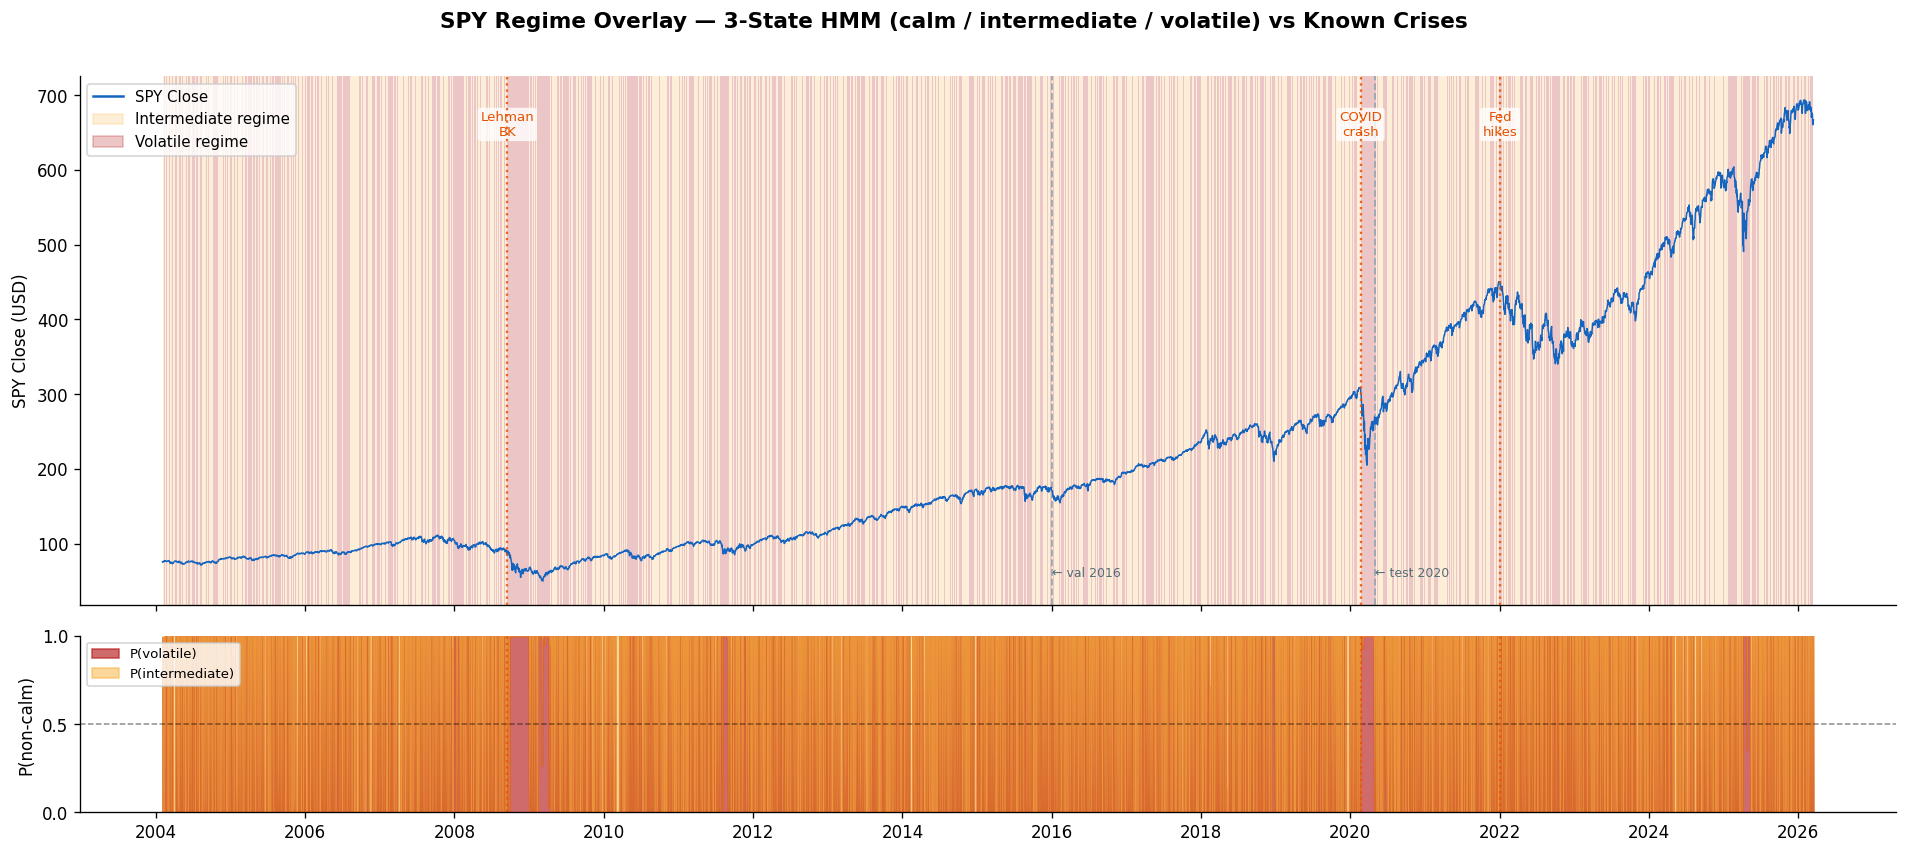

In [23]:
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

CRISIS_DATES = [
    ("2008-09-15", "Lehman\nBK"),
    ("2020-02-20", "COVID\ncrash"),
    ("2022-01-03", "Fed\nhikes"),
]
SPLIT_DATES = [
    (val_hmm_df.index[0],  "← val 2016"),
    (test_hmm_df.index[0], "← test 2020"),
]


def _shade_state(ax, dates, mask, color, alpha):
    in_span = False
    for i, (dt, v) in enumerate(zip(dates, mask)):
        if v and not in_span:
            span_start = dt
            in_span = True
        elif not v and in_span:
            ax.axvspan(span_start, dt, alpha=alpha, color=color, lw=0)
            in_span = False
    if in_span:
        ax.axvspan(span_start, dates[-1], alpha=alpha, color=color, lw=0)


is_volatile_mask     = all_states == volatile_state
is_intermediate_mask = all_states == intermediate_state

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
fig.suptitle(
    "SPY Regime Overlay — 3-State HMM (calm / intermediate / volatile) vs Known Crises",
    fontsize=13, fontweight="bold", y=1.01,
)

ax1.plot(all_dates, all_close.values, lw=0.9, color="#1565C0", label="SPY Close", zorder=3)
_shade_state(ax1, all_dates, is_intermediate_mask, color="#F9A825", alpha=0.18)
_shade_state(ax1, all_dates, is_volatile_mask,     color="#B71C1C", alpha=0.25)

for dt_obj, label in SPLIT_DATES:
    ax1.axvline(dt_obj, color="#90A4AE", ls="--", lw=1.1, alpha=0.9, zorder=2)
    ax1.text(dt_obj, all_close.min() * 1.04, label, fontsize=7.5,
             color="#546E7A", ha="left", va="bottom")

y_top = all_close.max()
for dt_str, label in CRISIS_DATES:
    dt = pd.Timestamp(dt_str)
    ax1.axvline(dt, color="#e65100", ls=":", lw=1.4, alpha=0.85, zorder=4)
    ax1.text(dt, y_top * 0.98, label, fontsize=8, color="#e65100",
             ha="center", va="top",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, lw=0))

ax1.set_ylabel("SPY Close (USD)", fontsize=10)
intermediate_patch = mpatches.Patch(color="#F9A825", alpha=0.18, label="Intermediate regime")
volatile_patch     = mpatches.Patch(color="#B71C1C", alpha=0.25, label="Volatile regime")
ax1.legend(
    handles=[
        plt.Line2D([0], [0], color="#1565C0", lw=1.5, label="SPY Close"),
        intermediate_patch,
        volatile_patch,
    ],
    fontsize=9, loc="upper left",
)

ax2.fill_between(all_dates, p_volatile, alpha=0.65, color="#B71C1C", label="P(volatile)")
ax2.fill_between(all_dates, p_volatile, p_volatile + p_intermediate,
                 alpha=0.45, color="#F9A825", label="P(intermediate)")
ax2.axhline(0.5, ls="--", lw=0.9, color="k", alpha=0.45)
ax2.set_ylim(0, 1)
ax2.set_ylabel("P(non-calm)", fontsize=10)
ax2.set_yticks([0, 0.5, 1])
ax2.legend(fontsize=8, loc="upper left")
for dt_str, _ in CRISIS_DATES:
    ax2.axvline(pd.Timestamp(dt_str), color="#e65100", ls=":", lw=1.4, alpha=0.75)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
fig.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()

In [24]:
regime_proba_df = pd.DataFrame(
    {
        "p_calm":         p_calm,
        "p_intermediate": p_intermediate,
        "p_volatile":     p_volatile,
        "viterbi_state":  all_states,
        "regime_label":   [label_by_state[s] for s in all_states],
    },
    index=all_dates,
)
regime_proba_df.index.name = "Date"

regime_proba_path = DATA_PROCESSED / "regime_probabilities_3state.parquet"
regime_proba_df.to_parquet(regime_proba_path)

print(f"Saved → {regime_proba_path}")
print(f"Shape : {regime_proba_df.shape}")
print()
print(regime_proba_df.head(3).to_string())
print("...")
print(regime_proba_df.tail(3).to_string())

Saved → /Users/changjiangliu/Desktop/StockVolatilitySight/data/processed/regime_probabilities_3state.parquet
Shape : (5564, 5)

              p_calm  p_intermediate     p_volatile  viterbi_state  regime_label
Date                                                                            
2004-02-03  1.000000    5.261544e-71  5.362889e-160              0          calm
2004-02-04  0.006708    2.590775e-04   9.930327e-01              2      volatile
2004-02-05  0.000036    9.999642e-01   7.723439e-20              1  intermediate
...
                  p_calm  p_intermediate    p_volatile  viterbi_state  regime_label
Date                                                                               
2026-03-12  6.149714e-18    3.789493e-10  1.000000e+00              2      volatile
2026-03-13  3.138593e-12    8.106626e-07  9.999992e-01              2      volatile
2026-03-16  9.294949e-12    1.000000e+00  1.804580e-14              1  intermediate


### Phase 2c — Findings

The 3-state HMM adds an **intermediate** regime between calm and volatile, intended to
capture moderate-vol clusters the 2-state model lumps into calm. Concrete numbers
(crisis alignment, regime counts, transition probabilities) are in the **Summary** cell
below — populated after execution so they always match the latest run.

**Regime probabilities saved** → `data/processed/regime_probabilities_3state.parquet`

| Column | Description |
|---|---|
| `p_calm` | P(calm \| O) — forward-backward soft probability |
| `p_intermediate` | P(intermediate \| O) — forward-backward soft probability |
| `p_volatile` | P(volatile \| O) — forward-backward soft probability |
| `viterbi_state` | Most-likely raw state index from Viterbi decode |
| `regime_label` | `"calm"`, `"intermediate"`, or `"volatile"` |


## 11. Summary

*Numbers below match the latest executed cells in this notebook (Phase 2a–2c, 3-state run).*

### Phase 2a — GaussianHMM vs GMMHMM (3 states)

| Model | k | val LL | val BIC | val AIC |
|---|---|---|---|---|
| **GMMHMM(states=3, mix=2)** ✅ | 473 | 5,340.97 | -7,374.25 | -9,735.95 |
| GMMHMM(states=3, mix=3) | 707 | 5,675.29 | -6,406.52 | -9,936.58 |
| GaussianHMM(states=3) | 239 | -2,858.41 | 7,388.15 | 6,194.82 |

**Winner: `GMMHMM(states=3, mix=2)`** — lowest val BIC by **967.73** vs the next-best candidate.

| Item | Value |
|---|---|
| HMM features (11) | `log_return`, `abs_return`, `oc_return`, `intraday_range`, `log_volume`, `rolling_mean/std_5/10/21` |
| Selection criterion | Validation BIC (lower = better) |
| State map | **calm = state 0**, **intermediate = state 1**, **volatile = state 2** |
| Regime split (train HMM rows, 3,000 days) | Calm: **1** (0.0%) · Intermediate: **1,589** (53.0%) · Volatile: **1,410** (47.0%) |
| Transition: P(stay calm \| calm) | **0.9685** → implied avg calm run **31.7** trading days (1.5 months) |
| Transition: P(stay intermediate \| intermediate) | **0.5488** → implied avg intermediate run **2.2** trading days (0.1 months) |
| Transition: P(stay volatile \| volatile) | **0.5131** → implied avg volatile run **2.1** trading days (0.1 months) |
| Model saved | `models/hmm_winner_3state.joblib` |
| Scaler saved | `models/hmm_scaler_3state.joblib` |
| Metadata saved | `models/hmm_meta_3state.joblib` |

---

### Phase 2b — Higher-Order Markov

| Strategy | n_states | n_features | k | val LL | val BIC | BIC Δ vs 2a winner |
|---|---|---|---|---|---|---|
| 1st-order winner (GMMHMM(states=3, mix=2)) | 3 | 11 | 473 | 5,340.97 | -7,374.25 | — |
| A: state-space aug — GaussianHMM(states=9) | 9 | 11 | 773 | -2,535.13 | 10,475.86 | +17,850.11 |
| B: feature aug — GaussianHMM(states=3, feats=22) | 3 | 22 | 833 | -5,519.95 | 16,864.31 | +24,238.56 |

**Verdict: 1st-order retained.** Neither 2nd-order strategy improves val BIC (best Δ = +17850.11 vs 1st-order `-7,374.25`).

---

### Phase 2c — Viterbi regime assignment (cells 36–38)

| Item | Value |
|---|---|
| Full timeline | **5,564** rows (2004-02-03 → 2026-03-16) |
| Full sample | Calm: **1** (0.0%) · Intermediate: **2,968** (53.3%) · Volatile: **2,595** (46.6%) |
| By split | train: calm=1 · int=1,589 · vol=1,410  ·  val: calm=0 · int=587 · vol=502  ·  test: calm=0 · int=792 · vol=683 |
| Soft probabilities | `data/processed/regime_probabilities_3state.parquet` |

---

**Comparison with 2-state baseline**: see `03_hmm_regime.ipynb` for the 2-state Summary
(winner `GMMHMM(states=2, mix=2)`, val BIC −16,772.06, volatile days 196/3,000 = 6.5%
on train). Directly compare the tables above against that cell.

The 3-state solution is degenerate: the "calm" label maps to a near-empty state (1 day total across 5,564) and the other two states switch every ~2 days despite penalized restart selection. Val BIC is ~9,400 worse than the 2-state winner — so on this data, 3 states doesn't buy anything.